In [1]:
%pip install -qq -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
import params

params.configure_renku_cuda()
device = params.select_device()
print(f'Using device: {device}')

/home/renku/work/convNPClimate/params.py:86: SyntaxWarning: assertion is always true, perhaps remove parentheses?
  assert (not (not self.SEASONAL_FEATURES and self.SEASONAL_FEATURES_IN_MLP),


Using device: cuda


In [3]:
# Training configuration - modify these parameters as needed
PW_FIRST_DATE        = '2017-01-01'
PW_LAST_DATE         = '2024-12-31'
PW_VALIDITY_THRESHOLD = 0.9

PARAMS = params.Params(
    VARIABLE='tmax',
    MODEL_TYPE='smacnp',
    CONTEXT_TYPE='peakweather',
    PW_TRAIN_FRAC=0.6,
    PW_VAL_FRAC=0.2,
    STATION_SPLIT_SEED=42,
    N_EPOCHS=30,
    N_FOLDS=5,
    TRIAL_NAME='test-2017-30e-5f-smacnp-pw',
    RUN_TYPE='cloud' if params.is_renku() else 'local',
    BATCH_SIZE=8 if params.is_renku() else 16,
    DEVICE=device,
    SEASONAL_FEATURES=True,
    # SMACNP architecture
    R_DIM=128,
    W_DIM=128,
    V_DIM=128,
    N_HEADS=4,
    SMACNP_HIDDEN=128,
    USE_PE=True,
    PE_DIM=32,
)



print(f"Configuration: {PARAMS}")

Configuration: Params(VARIABLE='tmax', DATA_YEAR_START=2023, SEASONAL_FEATURES=True, SEASONAL_FEATURES_IN_MLP=True, USE_ELEVATION=True, USE_MTPI=True, N_CHANNELS=128, N_BLOCKS=6, KERNEL_SIZE=5, LENGTH_SCALE=0.1, IN_CHANNELS=0, N_EPOCHS=30, BATCH_SIZE=8, LR=0.0005, PATIENCE=20, N_FOLDS=5, SEED=42, TRIAL_NAME='test-2017-30e-5f-smacnp-pw', RUN_TYPE='cloud', DEVICE=device(type='cuda'), ERA5_MAX_TEMP_GLOB=None, ERA5_GEOPOTENTIAL_GLOB=None, METEO_SWISS_MAX_TEMP_GLOB=None, HI_RES_TOPOGRAPHY_ZARR_PATH=None, MODEL_TYPE='smacnp', R_DIM=128, W_DIM=128, V_DIM=128, N_HEADS=4, SMACNP_HIDDEN=128, USE_PE=True, PE_DIM=32, PW_TRAIN_FRAC=0.6, PW_VAL_FRAC=0.2, STATION_SPLIT_SEED=42, CONTEXT_TYPE='peakweather')


In [4]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.optim as optim

import datasets as ds
import model_factory
import cloud_sync
import visualization as vis
from convCNP.training.training_elev import train_smacnp

/home/renku/work/.venv/lib/python3.13/site-packages/dirsync/syncer.py:104: SyntaxWarning: invalid escape sequence '\.'
  self._exclude.append('^\.dirsync$')


In [5]:
# Define all paths as local - these are where data will be read from
BASE_DIR = Path('.')
OUTPUT_DIR = BASE_DIR / 'trained_models' / PARAMS.TRIAL_NAME
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
BASE_DATASET_DIR = BASE_DIR / 'datasets'
REMOTE_OUTPUT_DIR = Path().cwd() / '..' / 'trained-models-mount' / PARAMS.TRIAL_NAME
REMOTE_DATASET_DIR = Path().cwd() / '..' / 'datasets-mount'

# Note: loading datasets on Renkulab directly from Polybox was no working well.
# Things do work if we first sync the files over to local storage and then load them
# locally.
cloud_sync.sync_from_cloud_if_needed(REMOTE_DATASET_DIR, BASE_DATASET_DIR, PARAMS.RUN_TYPE)

# Save data paths in params for reproducibility (used by predictions notebook)
PARAMS = PARAMS.with_data_paths(ds.build_data_paths(BASE_DATASET_DIR))

Cloud run detected. Syncing data from /home/renku/work/convNPClimate/../datasets-mount to datasets...
Synchronizing directory datasets with /home/renku/work/convNPClimate/../datasets-mount
Source directory: /home/renku/work/convNPClimate/../datasets-mount:
dirsync finished in 0.13 seconds.
29 directories parsed, 0 files copied

Dataset sync complete.


In [6]:
# Load PeakWeather stations (all valid stations, before split)
daily_tmax, stations_meta, valid_stations = ds.load_peakweather_stations(
    first_date=PW_FIRST_DATE,
    last_date=PW_LAST_DATE,
    validity_threshold=PW_VALIDITY_THRESHOLD,
)
pw_dates_pd = pd.DatetimeIndex(daily_tmax.index.date.astype(str))

# Seasonal features from PW time axis
pw_times_np = np.array(pw_dates_pd, dtype='datetime64[D]')
if PARAMS.SEASONAL_FEATURES:
    seasonal_features = ds.compute_seasonal_features(pw_times_np, device=device)
    print(f"Seasonal features shape: {seasonal_features.shape}")
else:
    seasonal_features = None


Loading PeakWeather stations (meteo_station) from 2017-01-01 to 2024-12-31 ...
  148 / 160 stations pass validity threshold (90%)
  Daily tmax shape: (2921, 148)  (2017-01-01 → 2024-12-30)
  Altitude range: [203, 3571] m
Computed seasonal features: torch.Size([2921, 2]), dtype: torch.float32
Seasonal features shape: torch.Size([2921, 2])


In [7]:
hi_res_elevation, hi_res_tpi = ds.load_high_res_topography(PARAMS.HI_RES_TOPOGRAPHY_ZARR_PATH)

Loading high-resolution topography from Zarr: datasets/topo_subset.zarr
Topography dataset dimensions: FrozenMappingWarningOnValuesAccess({'y': 12800, 'x': 14200})
DEM shape: (12800, 14200), dtype: int16
TPI (TPI_500M) shape: (12800, 14200), dtype: float32


In [8]:
# Split stations 60 / 20 / 20
train_stations, val_stations, test_stations = ds.split_peakweather_stations(
    valid_stations,
    train_frac=PARAMS.PW_TRAIN_FRAC,
    val_frac=PARAMS.PW_VAL_FRAC,
    seed=PARAMS.STATION_SPLIT_SEED,
)

# Compute normalization stats from train stations only
pw_metadata = ds.compute_pw_metadata(daily_tmax, train_stations)
print(f"PW metadata: mean={pw_metadata.data_mean:.2f} K, std={pw_metadata.data_std:.2f} K")


Station split: 88 train / 29 val / 31 test
PW train stats: mean=285.36 K, std=9.57 K
PW metadata: mean=285.36 K, std=9.57 K


In [9]:
x_context, y_context = ds.build_pw_station_tensors(
    daily_tmax=daily_tmax,
    station_ids=train_stations,
    stations_meta=stations_meta,
    hi_res_tpi=hi_res_tpi,
    metadata=pw_metadata,
    seasonal_features=seasonal_features,
    dates_pd=pw_dates_pd,
    device=device,
)
# y_context must be (T, N, 1) for SMACNP
y_context = y_context.unsqueeze(-1)
# Fill NaN context observations with 0 (normalized mean) so attention is not disrupted
y_context = torch.nan_to_num(y_context, nan=0.0)

print(f"x_context: {x_context.shape}  # (T, N_train, 6)")
print(f"y_context: {y_context.shape}  # (T, N_train, 1)")


x_context: torch.Size([2921, 88, 6])  # (T, N_train, 6)
y_context: torch.Size([2921, 88, 1])  # (T, N_train, 1)


In [10]:
params.set_seed(PARAMS.SEED)

In [11]:
stats_file = os.path.join(OUTPUT_DIR, 'stats.csv')

In [12]:
# Save config and PW metadata for prediction notebooks
PARAMS.save_json(OUTPUT_DIR / 'params.json')
ds.save_metadata_json(pw_metadata, OUTPUT_DIR / 'metadata.json')

# Build val targets once — fixed station set, no subsampling needed
x_target, y_target = ds.build_pw_station_tensors(
    daily_tmax=daily_tmax,
    station_ids=val_stations,
    stations_meta=stations_meta,
    hi_res_tpi=hi_res_tpi,
    metadata=pw_metadata,
    seasonal_features=seasonal_features,
    dates_pd=pw_dates_pd,
    device=device,
)
print(f"x_target: {x_target.shape}  # (T, N_val, 6)")
print(f"y_target: {y_target.shape}  # (T, N_val)")

STATS_HEADER = 'Fold,Mean absolute error,Pearson correlation,Spearman correlation,Epoch,train NLL,test NLL\n'

for fold in range(PARAMS.N_FOLDS):
    print(f'\nStarting fold {fold + 1}/{PARAMS.N_FOLDS}...\n')

    fold_stats_file = os.path.join(OUTPUT_DIR, f'stats_fold{fold}.csv')
    if not os.path.exists(fold_stats_file):
        with open(fold_stats_file, 'w') as f:
            f.write(STATS_HEADER)

    params.set_seed(PARAMS.SEED + fold)
    model, loss_fn, get_value_fn = model_factory.build_smacnp(PARAMS, x_context.shape[-1])
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=PARAMS.LR)

    train_smacnp(
        model=model,
        opt=optimizer,
        ll=loss_fn,
        x_context=x_context,
        y_context=y_context,
        x_target=x_target,
        y_target=y_target,
        output_dir=OUTPUT_DIR,
        get_value=get_value_fn,
        fold=fold,
        n_folds=PARAMS.N_FOLDS,
        n_epochs=PARAMS.N_EPOCHS,
        batch_size=PARAMS.BATCH_SIZE,
        patience=PARAMS.PATIENCE,
        stats_file=fold_stats_file,
        device=device,
    )

    cloud_sync.sync_to_cloud_if_needed(OUTPUT_DIR, REMOTE_OUTPUT_DIR, PARAMS.RUN_TYPE)

# Merge per-fold stats into a single stats.csv
fold_csvs = [os.path.join(OUTPUT_DIR, f'stats_fold{f}.csv') for f in range(PARAMS.N_FOLDS)]
pd.concat([pd.read_csv(p) for p in fold_csvs if os.path.exists(p)]).to_csv(
    os.path.join(OUTPUT_DIR, 'stats.csv'), index=False
)
print(f'\nTraining finished. Models saved in {OUTPUT_DIR}.')


x_target: torch.Size([2921, 29, 6])  # (T, N_val, 6)
y_target: torch.Size([2921, 29])  # (T, N_val)

Starting fold 1/5...

Built SMACNP with 308,995 trainable parameters
Fold 1/5 | Epoch 0 | train NLL 0.083 | test NLL 0.087 | med MAE 0.120 | elapsed 5s | est. remaining 142s
Fold 1/5 | Epoch 1 | train NLL 0.069 | test NLL 0.072 | med MAE 0.095 | elapsed 8s | est. remaining 114s
Fold 1/5 | Epoch 2 | train NLL 0.060 | test NLL 0.061 | med MAE 0.088 | elapsed 11s | est. remaining 103s
Fold 1/5 | Epoch 3 | train NLL 0.067 | test NLL 0.072 | med MAE 0.096 | elapsed 15s | est. remaining 96s
Fold 1/5 | Epoch 4 | train NLL 0.055 | test NLL 0.059 | med MAE 0.080 | elapsed 18s | est. remaining 90s
Fold 1/5 | Epoch 5 | train NLL 0.057 | test NLL 0.064 | med MAE 0.091 | elapsed 21s | est. remaining 85s
Fold 1/5 | Epoch 6 | train NLL 0.067 | test NLL 0.059 | med MAE 0.079 | elapsed 25s | est. remaining 80s
Fold 1/5 | Epoch 7 | train NLL 0.054 | test NLL 0.054 | med MAE 0.073 | elapsed 28s | est. rem

In [13]:
OUTPUT_DIR
fold_csvs = [os.path.join(OUTPUT_DIR, f'stats_fold{f}.csv') for f in range(PARAMS.N_FOLDS)]
pd.concat([pd.read_csv(p) for p in fold_csvs if os.path.exists(p)]).to_csv(stats_file, index=False)

In [14]:
print(stats_file)
stats = pd.read_csv(stats_file)
stats

trained_models/test-2017-30e-5f-smacnp-pw/stats.csv


,Fold,Mean absolute error,Pearson correlation,Spearman correlation,Epoch,train NLL,test NLL
0,0,0.120130,0.988250,0.989735,0,0.083371,0.087081
1,0,0.095401,0.992724,0.993646,1,0.068646,0.071942
2,0,0.087573,0.994008,0.994718,2,0.059817,0.061411
3,0,0.096114,0.993913,0.994645,3,0.067306,0.072050
4,0,0.079773,0.994437,0.994963,4,0.055353,0.058816
...,...,...,...,...,...,...,...
145,4,0.072800,0.993835,0.993892,25,0.052038,0.052290
146,4,0.074568,0.993756,0.993995,26,0.048357,0.054251
147,4,0.073395,0.994396,0.994310,27,0.048771,0.051723
148,4,0.079979,0.993974,0.994114,28,0.053430,0.057951


  Saved plot: trained_models/test-2017-30e-5f-smacnp-pw/trainingstats_fold0


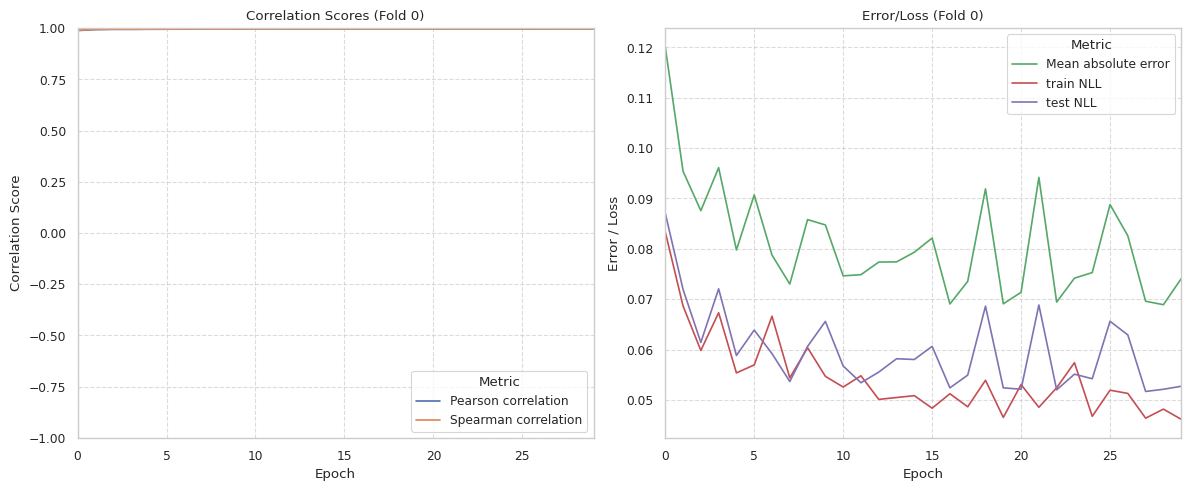

  Saved plot: trained_models/test-2017-30e-5f-smacnp-pw/trainingstats_fold1


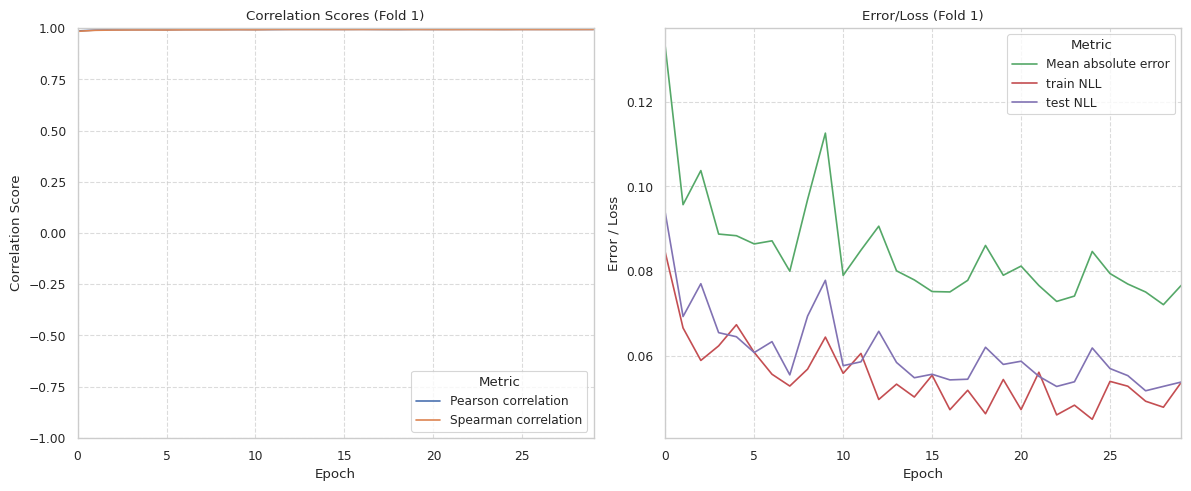

  Saved plot: trained_models/test-2017-30e-5f-smacnp-pw/trainingstats_fold2


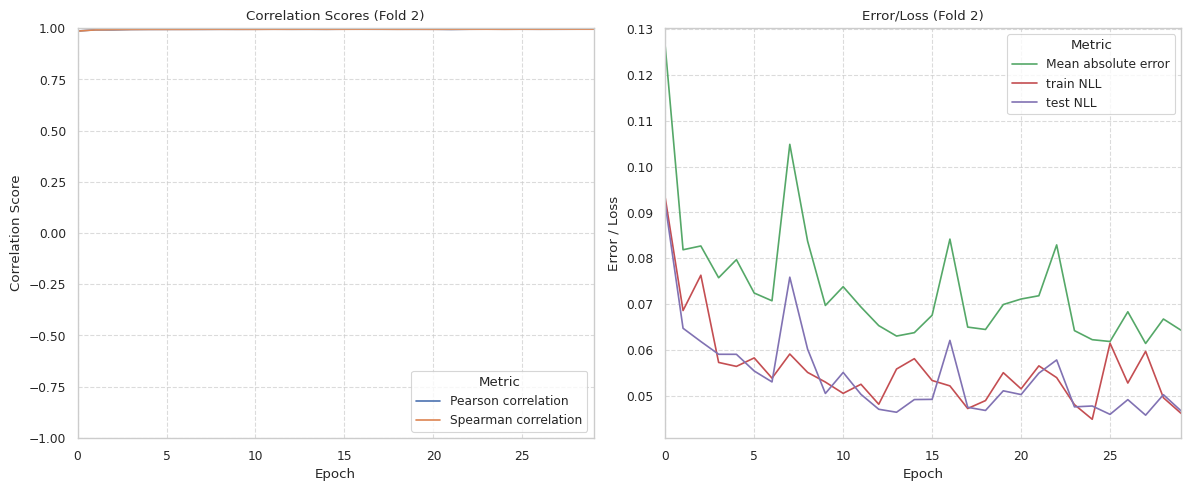

  Saved plot: trained_models/test-2017-30e-5f-smacnp-pw/trainingstats_fold3


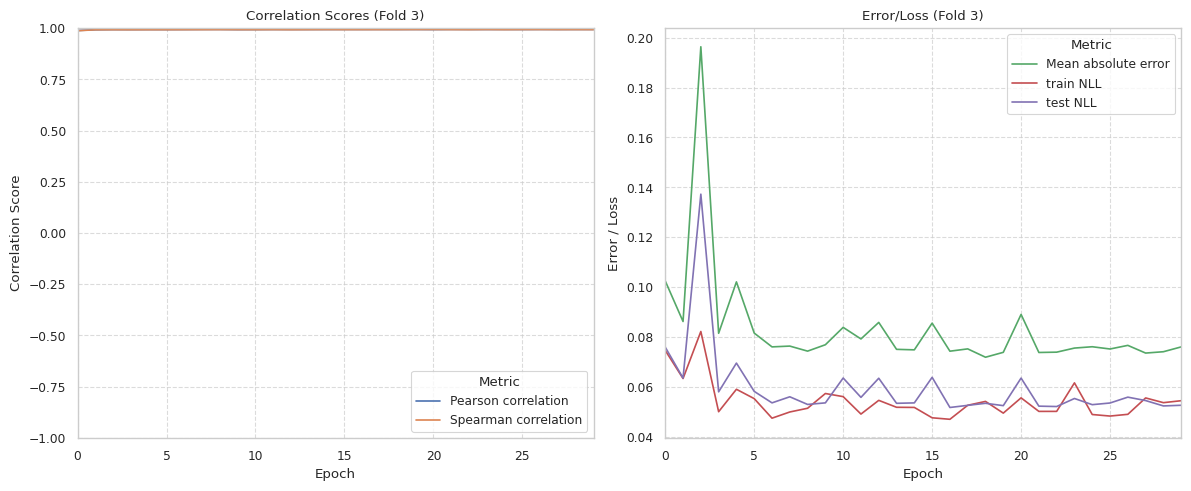

  Saved plot: trained_models/test-2017-30e-5f-smacnp-pw/trainingstats_fold4


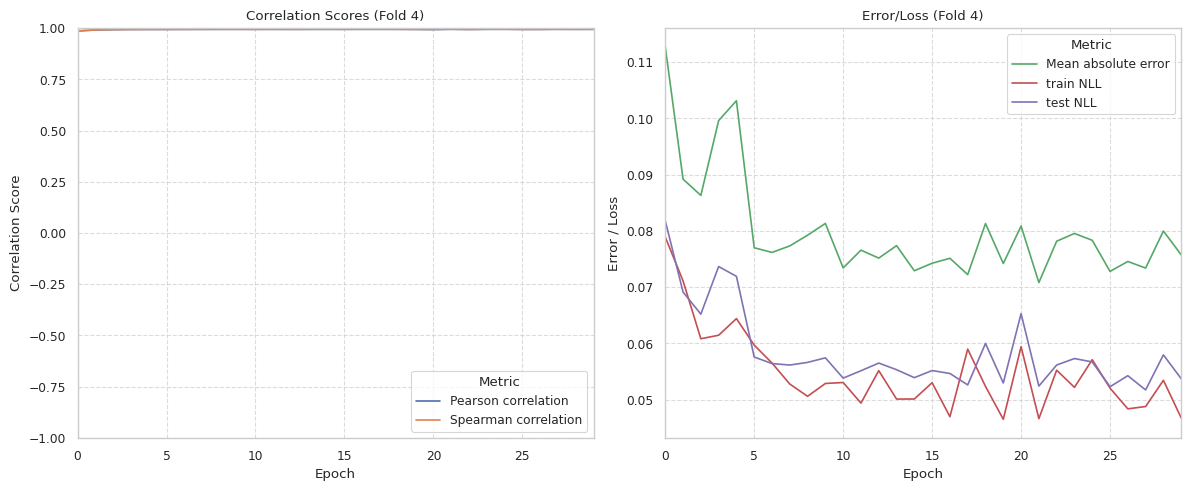

  Saved plot: trained_models/test-2017-30e-5f-smacnp-pw/trainingstats_all


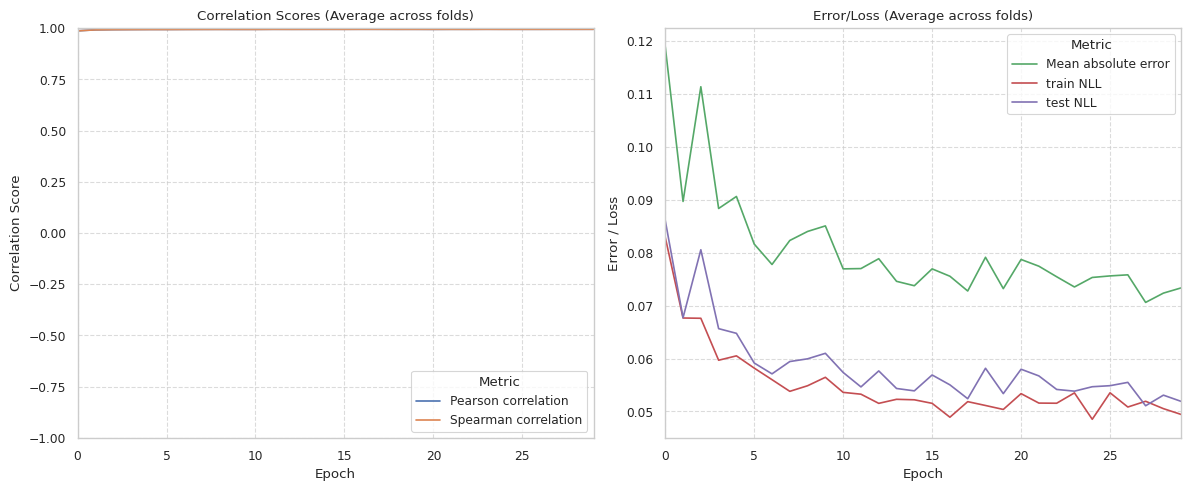

In [16]:
save_path_prefix = str(OUTPUT_DIR / 'trainingstats')
vis.plot_training_curves(stats, save_path=save_path_prefix)
plt.show()